<a href="https://colab.research.google.com/github/dragstoll/Hands-On-Python-Natural-Language-Processing/blob/master/Kopie_von_travel_agent_langgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧳 Travel Agent with LangGraph

> Add blockquote



> **GenAI Zürich 2026** — The European Summit on Applied Generative AI
>
> Workshop: *Designing LLM Agents: Frameworks, Architectures, and Trade-offs*
> David Limacher & Julian Schelb — [Artifact SA](https://artifact.swiss)

***


In this notebook we build a **travel agent** using [LangGraph](https://langchain-ai.github.io/langgraph/), a framework for building LLM applications as graphs of interconnected steps. Our agent can look up country facts, check the weather, summarise a city, and find nearby attractions, all by calling free public APIs as **tools**. We implement the same agent in **two different ways** to explore how the choice of reasoning pattern affects behaviour, cost, and complexity.

## Setup

### Dependencies

In [ ]:
%pip install -q langgraph langchain langchain-openai langchain-core requests

In [ ]:
import requests
from typing import TypedDict
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END

### Configuration

Set your API key, model name, and proxy URL here. No `.env` file needed — everything is configured in this cell.

In [ ]:
# Set values to connect to LITELLM
LITELLM_API_KEY = "sk-ShWF2pBHZUsDR9Bs4RTVYg"
MODEL_NAME      = "azure_ai/claude-sonnet-4-5-swc"
BASE_URL        = "https://litellm.artifact.swiss"

# Create LLM client
llm = ChatOpenAI(
    model=MODEL_NAME,
    base_url=BASE_URL,
    api_key=LITELLM_API_KEY,
)

# Quick sanity check
response = llm.invoke("Say hello in three languages.")
print(response.content)

Hello! Here are greetings in three languages:

1. **Spanish**: Hola
2. **French**: Bonjour
3. **Mandarin Chinese**: 你好 (Nǐ hǎo)


## Tools

Four plain Python functions that call **free, keyless APIs**. Both agent approaches (ReWOO and ReAct) use these same tools. It is only the orchestration that differs.

### Get Country Info

Uses the [REST Countries API](https://restcountries.com/) to look up basic facts about a destination: official name, capital city, currency, spoken languages, population, and world region.

In [ ]:
def get_country_info(country_name: str) -> dict:
    """Fetch country data from REST Countries API and return the full response."""
    try:
        resp = requests.get(
            f"https://restcountries.com/v3.1/name/{country_name}",
            timeout=10,
        )
        resp.raise_for_status()
        return resp.json()[0]
    except Exception as e:
        return {"error": str(e)}

In [ ]:
get_country_info("Switzerland")

{'tld': ['.ch'],
 'cca2': 'CH',
 'ccn3': '756',
 'cca3': 'CHE',
 'cioc': 'SUI',
 'independent': True,
 'status': 'officially-assigned',
 'unMember': True,
 'idd': {'root': '+4', 'suffixes': ['1']},
 'capital': ['Bern'],
 'altSpellings': ['CH',
  'Swiss Confederation',
  'Schweiz',
  'Suisse',
  'Svizzera',
  'Svizra'],
 'region': 'Europe',
 'subregion': 'Western Europe',
 'landlocked': True,
 'borders': ['AUT', 'FRA', 'ITA', 'LIE', 'DEU'],
 'area': 41284.0,
 'maps': {'googleMaps': 'https://goo.gl/maps/uVuZcXaxSx5jLyEC9',
  'openStreetMaps': 'https://www.openstreetmap.org/relation/51701'},
 'population': 9082848,
 'fifa': 'SUI',
 'car': {'signs': ['CH'], 'side': 'right'},
 'timezones': ['UTC+01:00'],
 'continents': ['Europe'],
 'flag': '🇨🇭',
 'name': {'common': 'Switzerland',
  'official': 'Swiss Confederation',
  'nativeName': {'fra': {'official': 'Confédération suisse',
    'common': 'Suisse'},
   'gsw': {'official': 'Schweizerische Eidgenossenschaft',
    'common': 'Schweiz'},
   'it

### Get Weather

Uses the [Open-Meteo API](https://open-meteo.com/) to fetch current conditions and a 3-day forecast. Since Open-Meteo needs coordinates, we first geocode the **city name** via their geocoding endpoint, then query the forecast endpoint. The raw JSON response is returned as-is.

A `WMO_CODES` lookup table maps numeric weather codes to human-readable descriptions (e.g. code 61 → "Slight rain").

In [ ]:
# WMO weather code → human-readable description
WMO_CODES = {
    0: "Clear sky", 1: "Mainly clear", 2: "Partly cloudy",
    3: "Overcast", 45: "Foggy", 51: "Light drizzle",
    61: "Slight rain", 71: "Slight snow", 80: "Rain showers",
    95: "Thunderstorm",
}


def geocode(city_name: str) -> dict:
    """Resolve a city name to lat/lon via Open-Meteo's geocoding API."""
    resp = requests.get(
        "https://geocoding-api.open-meteo.com/v1/search",
        params={"name": city_name, "count": 1},
        timeout=10,
    ).json()

    if "results" not in resp or len(resp["results"]) == 0:
        return {"error": f"'{city_name}' not found in geocoding API"}

    return resp["results"][0]


def get_forecast(lat: float, lon: float) -> dict:
    """Fetch current weather + 3-day forecast from Open-Meteo for given coordinates."""
    resp = requests.get(
        "https://api.open-meteo.com/v1/forecast",
        params={
            "latitude": lat,
            "longitude": lon,
            "current": "temperature_2m,weather_code,wind_speed_10m",
            "daily": "temperature_2m_max,temperature_2m_min",
            "forecast_days": 3,
            "timezone": "auto",
        },
        timeout=10,
    )
    resp.raise_for_status()
    return resp.json()


def get_weather(city_name: str) -> dict:
    """Geocode a city name and fetch weather from Open-Meteo."""
    try:
        location = geocode(city_name)
        if "error" in location:
            return location
        forecast = get_forecast(location["latitude"], location["longitude"])

        # Translate numeric weather_code → readable condition
        code = forecast.get("current", {}).get("weather_code")
        forecast["condition"] = WMO_CODES.get(code, f"Unknown (code {code})")

        return forecast
    except Exception as e:
        return {"error": str(e)}

In [ ]:
get_weather("Zurich")

{'latitude': 47.36,
 'longitude': 8.559999,
 'generationtime_ms': 0.11110305786132812,
 'utc_offset_seconds': 7200,
 'timezone': 'Europe/Zurich',
 'timezone_abbreviation': 'GMT+2',
 'elevation': 442.0,
 'current_units': {'time': 'iso8601',
  'interval': 'seconds',
  'temperature_2m': '°C',
  'weather_code': 'wmo code',
  'wind_speed_10m': 'km/h'},
 'current': {'time': '2026-04-02T12:15',
  'interval': 900,
  'temperature_2m': 7.1,
  'weather_code': 1,
  'wind_speed_10m': 6.2},
 'daily_units': {'time': 'iso8601',
  'temperature_2m_max': '°C',
  'temperature_2m_min': '°C'},
 'daily': {'time': ['2026-04-02', '2026-04-03', '2026-04-04'],
  'temperature_2m_max': [11.6, 14.2, 14.2],
  'temperature_2m_min': [0.8, 4.6, 8.0]},
 'condition': 'Mainly clear'}

### Get City Summary

Uses the [Wikipedia TextExtracts API](https://www.mediawiki.org/wiki/Extension:TextExtracts) to fetch a plain-text extract of the city's article. This retrieves history, geography, culture, and more in a single call.

In [ ]:
# Wikipedia requires a User-Agent header for API access
WIKI_HEADERS = {"User-Agent": "TravelAgentWorkshop/1.0 (workshop demo)"}


def get_city_summary(city_name: str, chars: int = 4000) -> str:
    """Fetch a plain-text extract of a city's Wikipedia article."""
    try:
        resp = requests.get(
            "https://en.wikipedia.org/w/api.php",
            params={
                "action": "query",
                "titles": city_name,
                "prop": "extracts",
                "explaintext": True,
                "exchars": chars,
                "format": "json",
            },
            headers=WIKI_HEADERS,
            timeout=10,
        ).json()
        pages = resp.get("query", {}).get("pages", {})
        page = next(iter(pages.values()), {})
        return page.get("extract", "") or "No Wikipedia article found."
    except Exception as e:
        return f"Error: {e}"

In [ ]:
get_city_summary("Zurich")

"Zurich (German: Zürich; Alemannic German: Züri; see below) is the largest city in Switzerland and the capital of the canton of Zurich. It is in north-central Switzerland, at the northwestern tip of Lake Zurich. As of the end of 2024, the municipality had a population of 436,551, while the urban area was home to 1.45 million people (2020), and the Zurich metropolitan area had a total population of 2.1 million (2020). Zurich is a hub for railways, roads, and air traffic. Both Zurich Airport and Zurich's main railway station are the largest and busiest in the country.\nEvidence of early, sparse settlements in the area dates back more than 6,400 years, indicating human presence prior to the establishment of the town. Permanently settled for over 2,000 years, Zurich was eventually founded by the Romans, who called it Turicum. During the Middle Ages, Zurich gained the independent and privileged status of imperial immediacy and, in 1519, became a primary centre of the Protestant Reformation 

### Get Nearby Attractions

Uses Wikipedia's [geosearch API](https://www.mediawiki.org/wiki/Extension:GeoData) to find notable places near the destination. Reuses `geocode()` from the weather tool to resolve the city name to coordinates, then queries for Wikipedia articles within a 10 km radius.

In [ ]:
def get_attractions(city_name: str, radius: int = 10000, limit: int = 10) -> list[str]:
    """Find notable places near a city using Wikipedia's geosearch."""
    try:
        loc = geocode(city_name)
        if "error" in loc:
            return [f"Error: {loc['error']}"]

        resp = requests.get(
            "https://en.wikipedia.org/w/api.php",
            params={
                "action": "query",
                "list": "geosearch",
                "gscoord": f"{loc['latitude']}|{loc['longitude']}",
                "gsradius": radius,
                "gslimit": limit,
                "format": "json",
            },
            headers=WIKI_HEADERS,
            timeout=10,
        ).json()

        places = resp.get("query", {}).get("geosearch", [])
        return [p["title"] for p in places if p["title"].lower() != city_name.lower()]
    except Exception as e:
        return [f"Error: {e}"]

In [ ]:
get_attractions("Zurich")

['Zurich metropolitan area',
 'ACentauri Solar Racing',
 'History of Zurich',
 'Eurovapor',
 'Canton of Zurich',
 'Psychology Club Zürich',
 'Zurich Stadelhofen railway station',
 'Zürich Stadelhofen FB railway station',
 'Swiss Social Archives',
 'Zurich Opera House']

## Approach 1: ReWOO

**ReWOO** (Reasoning WithOut Observation) separates *planning* from *execution*. The LLM creates a complete plan upfront by deciding which tools to call and then a worker executes all calls, and finally a solver synthesizes the results into an answer.




In [ ]:
import json

class ReWOOState(TypedDict):
    query: str        # original user input
    plan: list        # planned tool calls: [{"tool": "...", "args": "..."}, ...]
    results: dict     # tool_name → result
    answer: str       # final synthesized answer

### Planner

The planner asks the LLM to decide **which tools to call** based on the user's query. It returns a JSON list of tool calls — no tools are executed yet. The plan is pure intent.

In [ ]:
import re

PLANNER_PROMPT = """\
You are a travel planning assistant. Given a user query, decide which tools to call.

Available tools:
- get_country_info(country_name) — country facts (capital, currency, population)
- get_weather(city_name) — current weather + 3-day forecast
- get_city_summary(city_name) — Wikipedia summary of a city
- get_attractions(city_name) — notable places near a city

Return a JSON list of tool calls. Each entry has "tool" (function name) and "args" (single string argument).

Example:
[{"tool": "get_country_info", "args": "Japan"}, {"tool": "get_weather", "args": "Tokyo"}]

Return ONLY the JSON list, no other text."""


def parse_json(text: str) -> list:
    """Extract a JSON list from LLM output, stripping markdown fences if present."""
    # Try to find JSON inside ```json ... ``` or ``` ... ```
    match = re.search(r"```(?:json)?\s*(.*?)\s*```", text, re.DOTALL)
    return json.loads(match.group(1) if match else text)


def planner(state: ReWOOState) -> dict:
    """LLM decides which tools to call — no execution yet."""
    print("📋 Planning tool calls...")
    response = llm.invoke([
        ("system", PLANNER_PROMPT),
        ("human", state["query"]),
    ])
    plan = parse_json(response.content)
    print(f"   → Plan: {[step['tool'] for step in plan]}")
    return {"plan": plan}

### Worker

The worker receives the plan and executes every tool call. A lookup table maps tool names to the Python functions we defined earlier. No LLM is involved here — just deterministic function calls.

In [ ]:
TOOLS = {
    "get_country_info": get_country_info,
    "get_weather": get_weather,
    "get_city_summary": get_city_summary,
    "get_attractions": get_attractions,
}


def worker(state: ReWOOState) -> dict:
    """Execute all planned tool calls."""
    results = {}
    for step in state["plan"]:
        name, args = step["tool"], step["args"]
        print(f"🔧 Calling {name}({args!r})...")
        results[name] = TOOLS[name](args)
    print(f"   → Collected {len(results)} results")
    return {"results": results}

### Solver

The solver is the only node that sees actual tool results. It receives **all** collected data at once and writes the final travel briefing — the second and last LLM call.

In [ ]:
SOLVER_PROMPT = """\
You are a friendly travel assistant. Write a concise travel briefing \
based on the collected data. Structure it as:
1. Country basics (name, capital, currency, language)
2. Current weather + packing advice
3. Top attractions or things to know

Keep it under 250 words. If some data is missing, work with what you have."""


def solver(state: ReWOOState) -> dict:
    """LLM synthesizes all tool results into a travel briefing."""
    print("✍️  Solving...")
    context = json.dumps(state["results"], indent=2, default=str)
    response = llm.invoke([
        ("system", SOLVER_PROMPT),
        ("human", f"Query: {state['query']}\n\nCollected data:\n{context}"),
    ])
    return {"answer": response.content}

### Build & Run

The ReWOO graph is a simple linear chain.

```
planner → worker → solver → END
```

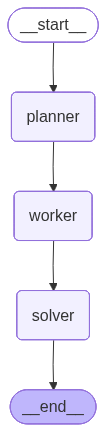

In [ ]:
# Add nodes to the graph
rewoo_builder = StateGraph(ReWOOState)
rewoo_builder.add_node("planner", planner)
rewoo_builder.add_node("worker", worker)
rewoo_builder.add_node("solver", solver)

# Define edges between nodes
rewoo_builder.set_entry_point("planner")
rewoo_builder.add_edge("planner", "worker")
rewoo_builder.add_edge("worker", "solver")
rewoo_builder.add_edge("solver", END)

# Compile the graph and visualize it
rewoo_graph = rewoo_builder.compile()

try:
    from IPython.display import Image, display
    display(Image(rewoo_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(rewoo_graph.get_graph().draw_mermaid())

In [ ]:
result = rewoo_graph.invoke({
    "query": "I'm planning a trip to Tokyo next month. What should I know?",
    "plan": [],
    "results": {},
    "answer": "",
})

print("\n" + "=" * 60)
print("📝 TRAVEL BRIEFING (ReWOO)")
print("=" * 60)
print(result["answer"])

📋 Planning tool calls...
   → Plan: ['get_country_info', 'get_weather', 'get_city_summary', 'get_attractions']
🔧 Calling get_country_info('Japan')...
🔧 Calling get_weather('Tokyo')...
🔧 Calling get_city_summary('Tokyo')...
🔧 Calling get_attractions('Tokyo')...
   → Collected 4 results
✍️  Solving...

📝 TRAVEL BRIEFING (ReWOO)
# Your Tokyo Travel Briefing 🇯🇵

## Country Basics
**Japan** (Nippon/Nihon) is an island nation in Eastern Asia with Tokyo as its capital. The currency is the Japanese Yen (¥), and the official language is Japanese. With over 123 million people, Japan is known for its blend of ancient traditions and cutting-edge technology. Important note: traffic drives on the **left side** of the road.

## Current Weather & Packing Tips
Tokyo is experiencing pleasant spring weather with temperatures around 11-18°C (52-64°F). Expect clear skies and mild conditions. **Pack:** Light layers including a jacket for cooler mornings/evenings, comfortable walking shoes, and an umbrella j

## Approach 2: ReAct

**ReAct** (Reasoning + Acting) interleaves reasoning and tool use in a loop. The LLM decides which tool to call, observes the result, then decides what to do next. This is repeated until it has enough information to answer.



### Tool Wrappers

ReAct requires tools to be registered with the LLM using LangChain's `@tool` decorator. This lets the LLM discover available tools and their descriptions, then decide which to call. We wrap our existing functions so the LLM can invoke them by name.

In [ ]:
from langchain_core.tools import tool


@tool
def search_country(country_name: str) -> str:
    """Look up country facts like capital, currency, population, and languages."""
    print(f"🔧 search_country({country_name!r})")
    return json.dumps(get_country_info(country_name), default=str)


@tool
def search_weather(city_name: str) -> str:
    """Get current weather and 3-day forecast for a city."""
    print(f"🔧 search_weather({city_name!r})")
    return json.dumps(get_weather(city_name), default=str)


@tool
def search_city_summary(city_name: str) -> str:
    """Get a Wikipedia summary about a city covering history, culture, and geography."""
    print(f"🔧 search_city_summary({city_name!r})")
    return get_city_summary(city_name)


@tool
def search_attractions(city_name: str) -> str:
    """Find notable places and attractions near a city."""
    print(f"🔧 search_attractions({city_name!r})")
    return json.dumps(get_attractions(city_name), default=str)


travel_tools = [search_country, search_weather, search_city_summary, search_attractions]

### Build & Run

LangGraph provides `create_react_agent` which wires up the full reasoning-acting loop automatically. Under the hood it creates a graph with an LLM node and a tool-execution node connected by a conditional edge.

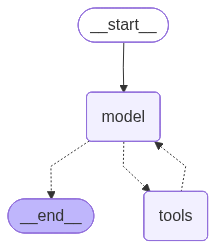

In [ ]:
from langchain.agents import create_agent
react_agent = create_agent(llm, travel_tools)

try:
    from IPython.display import Image, display
    display(Image(react_agent.get_graph().draw_mermaid_png()))
except Exception:
    print(react_agent.get_graph().draw_mermaid())

In [ ]:
result = react_agent.invoke(
    {"messages": [("human", "I'm planning a trip to Tokyo next month. What should I know?")]},
    print_mode="human",
)

print("\n" + "=" * 60)
print("📝 TRAVEL BRIEFING (ReAct)")
print("=" * 60)
print(result["messages"][-1].content)

🔧 search_city_summary('Tokyo')
🔧 search_country('Japan')
🔧 search_weather('Tokyo')
🔧 search_attractions('Tokyo')

📝 TRAVEL BRIEFING (ReAct)
Great! Here's what you should know for your trip to Tokyo:

## **Country Basics - Japan**
- **Currency**: Japanese Yen (¥)
- **Language**: Japanese
- **Population**: ~123 million (Tokyo metro area: 41 million!)
- **Timezone**: UTC+9 (Japan Standard Time)
- **Driving**: Left side of the road
- **Dialing code**: +81

## **About Tokyo**
Tokyo is Japan's capital and one of the world's most populous metropolitan areas with over 14 million people in the city proper. It's located on the central coast of Honshu (Japan's largest island) at the head of Tokyo Bay. Tokyo is Japan's economic center and home to the Japanese government and the Emperor.

## **Weather Forecast**
Currently in Tokyo it's **11.4°C (52°F)** with clear skies. The next few days show:
- **Today**: High 16°C, Low 9°C
- **Tomorrow**: High 18°C, Low 6°C
- **Day after**: High 17°C, Low 10°C



## Try Your Own

Change the query below and re-run to compare both approaches on the same destination!

In [ ]:
YOUR_QUERY = "I want to visit Geneva in December"

# --- ReWOO ---
rewoo_result = rewoo_graph.invoke({
    "query": YOUR_QUERY, "plan": [], "results": {}, "answer": "",
})
print(rewoo_result["answer"])

# --- ReAct ---
react_result = react_agent.invoke({
    "messages": [("human", YOUR_QUERY)]
})
print(react_result["messages"][-1].content)

📋 Planning tool calls...
   → Plan: ['get_country_info', 'get_weather', 'get_city_summary', 'get_attractions']
🔧 Calling get_country_info('Switzerland')...
🔧 Calling get_weather('Geneva')...
🔧 Calling get_city_summary('Geneva')...
🔧 Calling get_attractions('Geneva')...
   → Collected 4 results
✍️  Solving...
# Your Geneva Travel Briefing 🇨🇭

## Country Basics
**Switzerland** (capital: Bern) is a landlocked Western European nation known for its stunning alpine scenery and multicultural heritage. The currency is the **Swiss franc (CHF)**, and while Switzerland has four official languages, Geneva is in the French-speaking region. English is widely understood in tourist areas.

## December Weather & Packing
Geneva experiences cold winters in December, with temperatures typically ranging from **1-5°C** (34-41°F). Expect partly cloudy to overcast skies, and be prepared for occasional snow or rain. 

**Pack:** Warm layers, a waterproof winter coat, gloves, scarf, and sturdy waterproof boots. 